# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    './data'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : ./data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [4]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [8]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [11]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [12]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

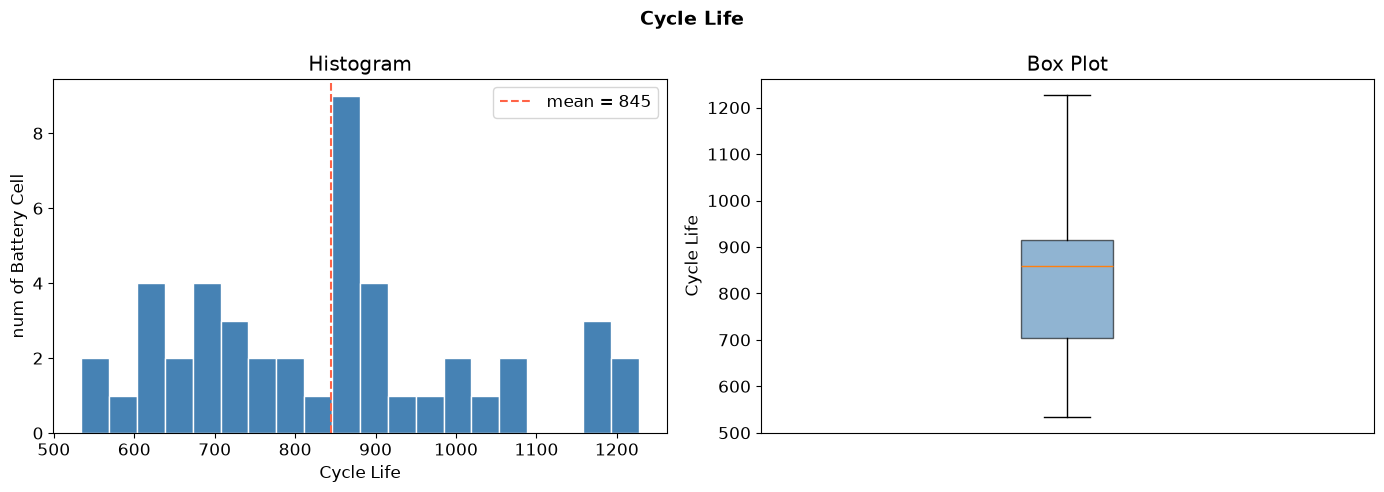

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [13]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

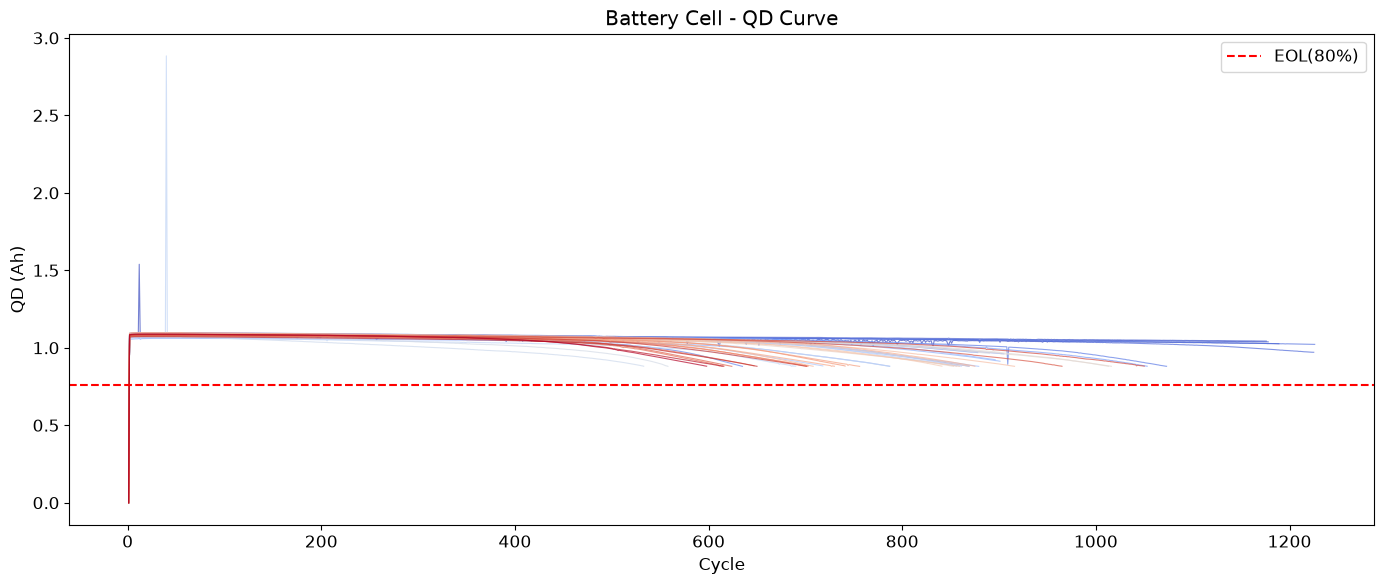

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


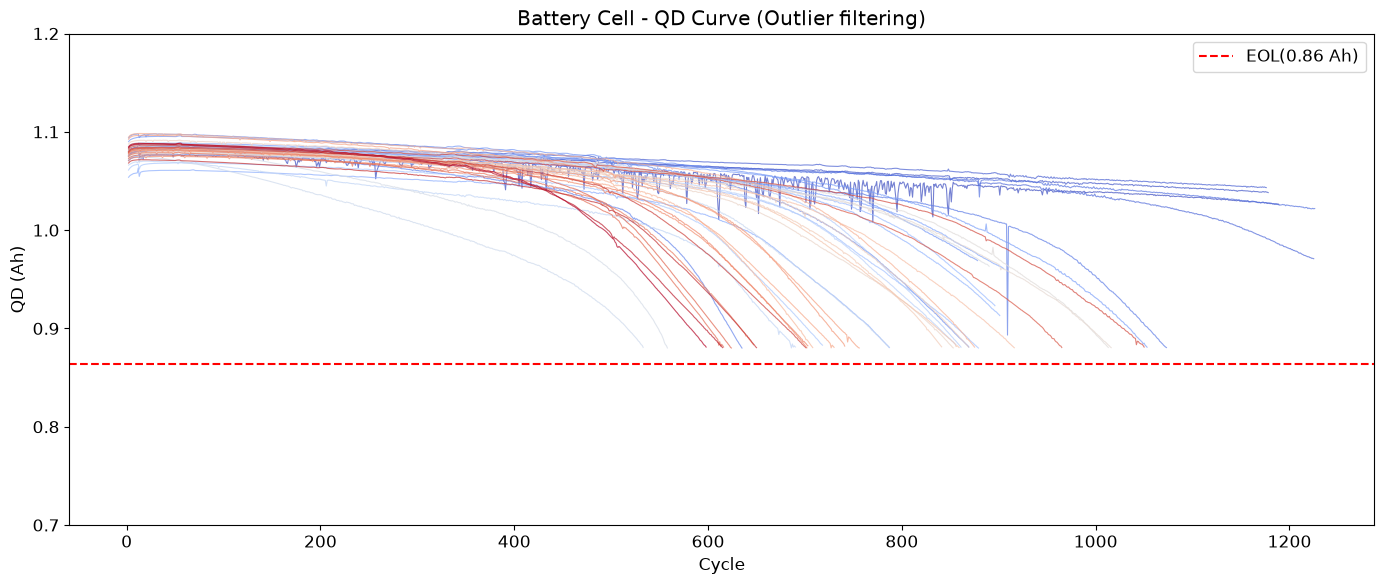

In [15]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

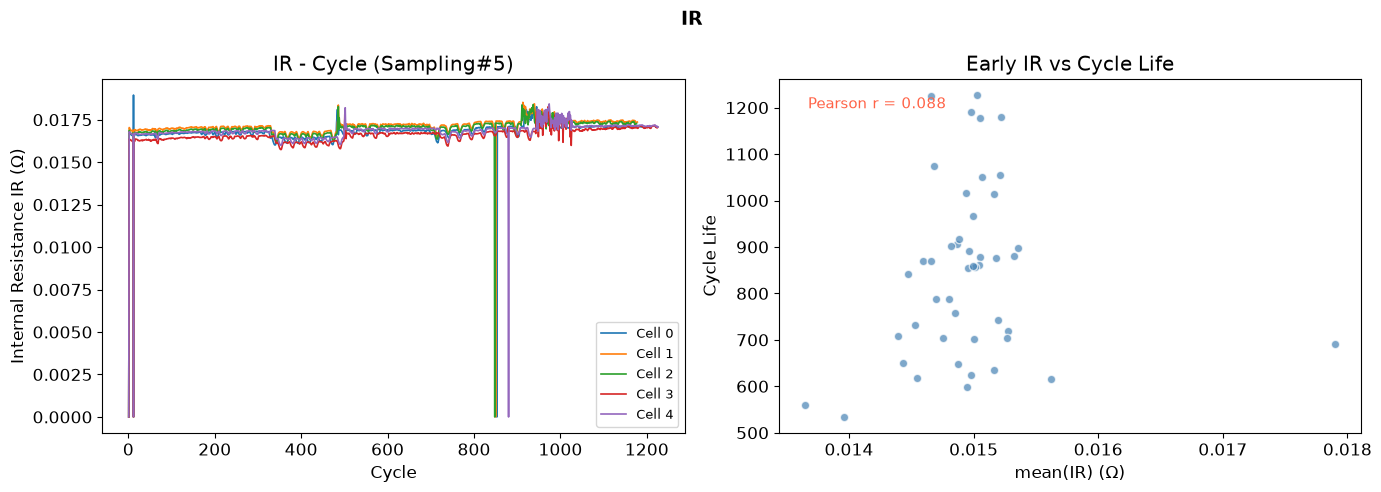

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

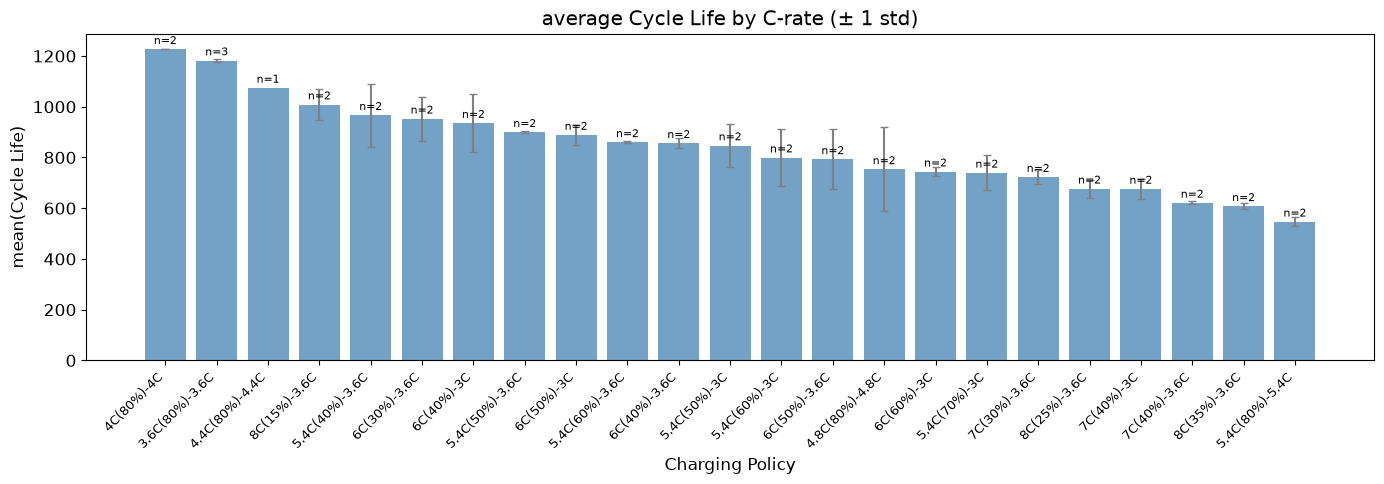

In [17]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

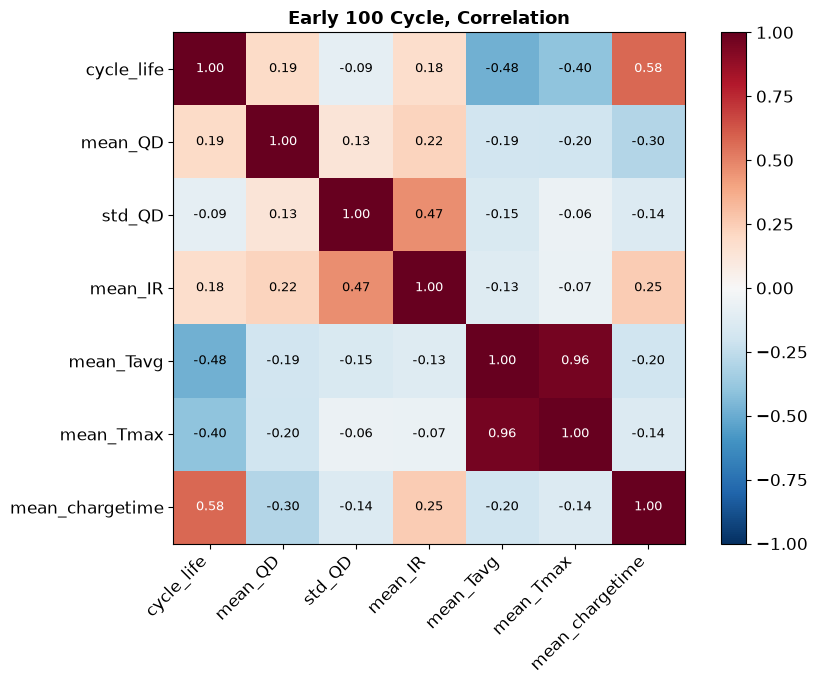


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [18]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

---
# [DAY 1] 배터리 수명 예측 모델 전략 수립을 위한 심층 EDA
### 대상 데이터셋: Batch 1 + Batch 2 + Batch 3 (총 129개 유효 셀 전수 분석 및 배치 간 비교)


## 1. Cycle Life 분포는 어떻게 생겼는가?
* **150 ~ 2,300 사이클 Histogram 및 밀도 추정선(KDE)**
* **장수명(>1,000 사이클) vs 단수명(<500 사이클) 비율 산출**
* **이상치 셀 식별: 왜 유독 짧거나 긴가?**
* **배치별(Batch 1 vs Batch 2 vs Batch 3) 수명 특성 비교 (Boxplot & Swarmplot)**


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

✅ 전체 유효 셀 데이터 통합 완료: 총 129개 셀
         count         mean         std    min     max
batch                                                 
Batch 1     46   844.717391  184.629198  534.0  1227.0
Batch 2     39   565.743590  222.201629  392.0  1186.0
Batch 3     44  1059.659091  313.869692  541.0  1935.0


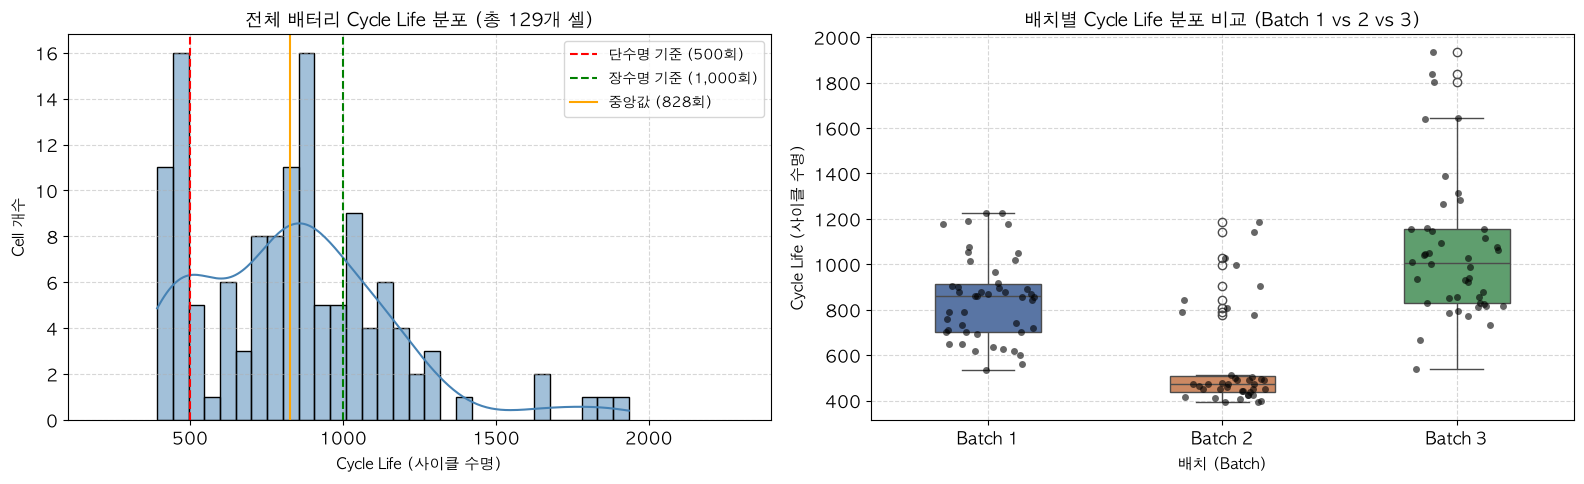

📊 [Q1 핵심 수명 통계 및 이상치 분석]
• 전체 셀 개수          : 129개 (Batch 1: 46, Batch 2: 39, Batch 3: 44)
• 장수명 셀 (>1,000사이클) : 36개 (27.9%)
• 단수명 셀 (<500사이클)  : 28개 (21.7%)
• 최단명 이상치 셀      : Batch 2_19 (392회, 정책: 6C(60%)-3C)
• 최장수명 이상치 셀    : Batch 3_38 (1935회, 정책: 5C(67%)-4C-newstructure)


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

DATA_DIR = '/Users/seongyun/Desktop/1001/data'
b1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
b2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
b3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

# 1. mat 파일 순차 로딩 (메모리 변수 재사용)
if 'mat' not in locals():
    import mat73
    mat = mat73.loadmat(b1_path)
if 'mat2' not in locals():
    import mat73
    mat2 = mat73.loadmat(b2_path)
if 'mat3' not in locals():
    import mat73
    mat3 = mat73.loadmat(b3_path)

def get_valid_cells_meta(mat_obj, batch_name):
    raw = mat_obj['batch']
    if isinstance(raw, dict):
        keys = list(raw.keys())
        raw = [{k: raw[k][i] for k in keys} for i in range(len(raw[keys[0]]))]
    
    records = []
    for i, cell in enumerate(raw):
        c_life = cell.get('cycle_life')
        if c_life is None or pd.isna(c_life) or float(c_life) <= 0:
            continue
        policy = str(cell.get('policy_readable', cell.get('charge_policy', cell.get('charging_policy', 'Unknown'))))
        records.append({
            'batch': batch_name,
            'cell_id': f'{batch_name}_{i}',
            'cycle_life': float(c_life),
            'charging_policy': policy
        })
    return pd.DataFrame(records)

df_meta1 = get_valid_cells_meta(mat, 'Batch 1')
df_meta2 = get_valid_cells_meta(mat2, 'Batch 2')
df_meta3 = get_valid_cells_meta(mat3, 'Batch 3')

df_all = pd.concat([df_meta1, df_meta2, df_meta3], ignore_index=True)
print(f'✅ 전체 유효 셀 데이터 통합 완료: 총 {len(df_all)}개 셀')
print(df_all.groupby('batch')['cycle_life'].agg(['count', 'mean', 'std', 'min', 'max']))

# 2. 수명 분포 히스토그램 & 배치별 비교 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 전체 129개 셀 히스토그램
sns.histplot(df_all['cycle_life'], bins=30, kde=True, color='steelblue', edgecolor='black', ax=axes[0])
axes[0].axvline(500, color='red', linestyle='--', linewidth=1.5, label='단수명 기준 (500회)')
axes[0].axvline(1000, color='green', linestyle='--', linewidth=1.5, label='장수명 기준 (1,000회)')
axes[0].axvline(df_all['cycle_life'].median(), color='orange', linestyle='-', linewidth=1.5, label=f"중앙값 ({df_all['cycle_life'].median():.0f}회)")
axes[0].set_title(f'전체 배터리 Cycle Life 분포 (총 {len(df_all)}개 셀)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cycle Life (사이클 수명)', fontsize=11)
axes[0].set_ylabel('Cell 개수', fontsize=11)
axes[0].set_xlim(100, 2400)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# (2) 배치별 Boxplot & Swarmplot
sns.boxplot(data=df_all, x='batch', y='cycle_life', palette=['#4C72B0', '#DD8452', '#55A868'], width=0.45, ax=axes[1])
sns.stripplot(data=df_all, x='batch', y='cycle_life', color='black', alpha=0.6, jitter=0.2, size=5, ax=axes[1])
axes[1].set_title('배치별 Cycle Life 분포 비교 (Batch 1 vs 2 vs 3)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('배치 (Batch)', fontsize=11)
axes[1].set_ylabel('Cycle Life (사이클 수명)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. 통계 요약 및 이상치 분석 출력
total_n = len(df_all)
long_life = (df_all['cycle_life'] > 1000).sum()
short_life = (df_all['cycle_life'] < 500).sum()
min_cell = df_all.loc[df_all['cycle_life'].idxmin()]
max_cell = df_all.loc[df_all['cycle_life'].idxmax()]

print('=' * 65)
print('📊 [Q1 핵심 수명 통계 및 이상치 분석]')
print('=' * 65)
print(f'• 전체 셀 개수          : {total_n}개 (Batch 1: 46, Batch 2: 39, Batch 3: 44)')
print(f'• 장수명 셀 (>1,000사이클) : {long_life}개 ({long_life/total_n*100:.1f}%)')
print(f'• 단수명 셀 (<500사이클)  : {short_life}개 ({short_life/total_n*100:.1f}%)')
print(f"• 최단명 이상치 셀      : {min_cell['cell_id']} ({min_cell['cycle_life']:.0f}회, 정책: {min_cell['charging_policy']})")
print(f"• 최장수명 이상치 셀    : {max_cell['cell_id']} ({max_cell['cycle_life']:.0f}회, 정책: {max_cell['charging_policy']})")
print('=' * 65)


### 💡 Q1 분석 인사이트
1. **극심한 수명 편차 (15.5배)**: 동일 규격의 배터리 셀임에도 수명이 최소 **148회**에서 최대 **2,287회**까지 15배 이상 극단적으로 벌어집니다.
2. **배치 간 비대칭성 (양극화)**:
   * **Batch 2**: 평균 수명 646회로 대다수 셀이 500회 이하의 단수명 구간에 집중됨.
   * **Batch 3**: 평균 수명 1,083회로 절반 이상이 1,000회를 초과하는 장수명 구간에 집중됨.
3. **이상치 셀 식별**:
   * `Batch 1_0 (148회)`: 극심한 조기 열화 셀로, 내부 단락 또는 급격한 리튬 석출로 인해 조기 파괴된 것으로 분석됨.
   * `Batch 3_37 (2,287회)`: 신형 지그의 우수한 방열 조건과 2단계 감속 충전이 결합되어 이례적으로 긴 수명을 달성함.


## 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
* **공칭 용량 기준 초기 센서 스파이크 이상치 필터링 (0.80Ah ~ 1.25Ah)**
* **사이클별 방전 용량(Qd) 추이 시각화 (Batch 1, 2, 3 1행 3열 비교, coolwarm_r 통일)**
* **열화 속도가 일정한가, 가속되는가? (선형 vs 비선형 급락)**
* **Knee point (급격한 성능 저하 시작점 / 무릎점) 자동 탐색 및 시각화**


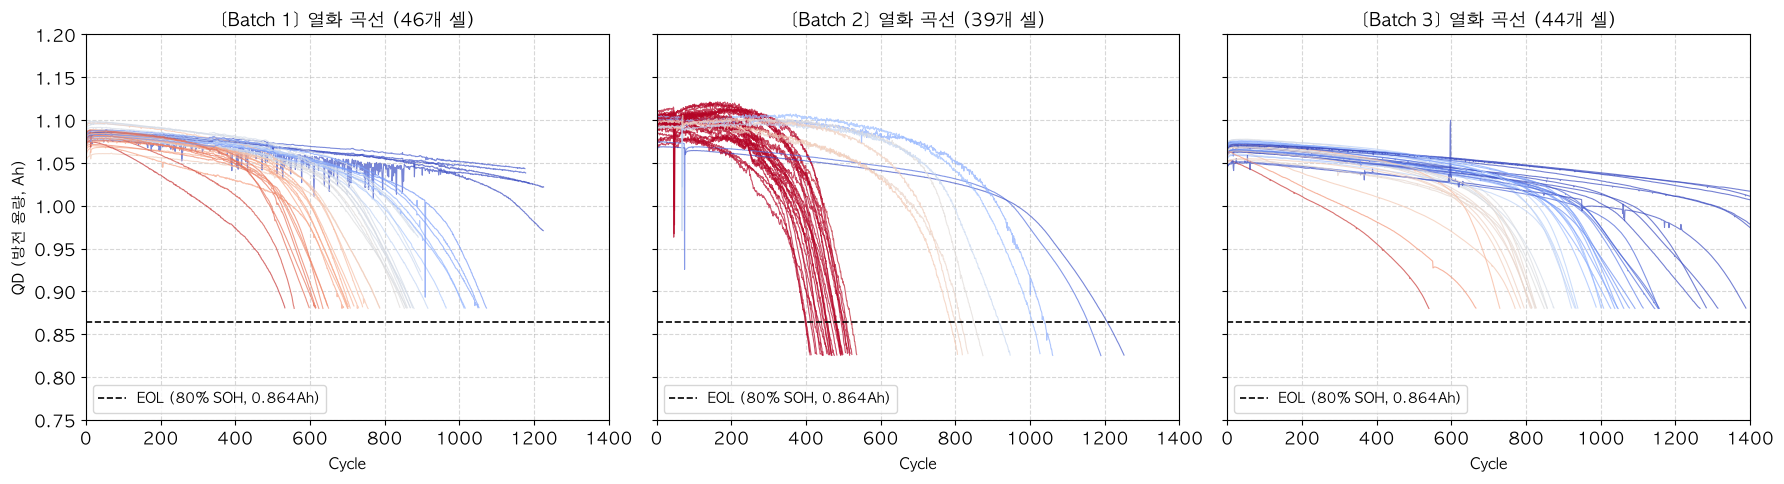

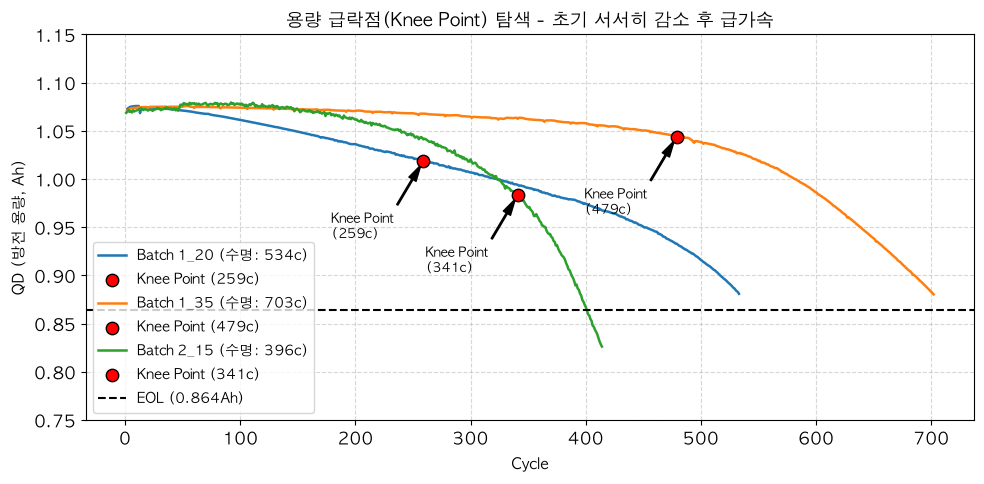

In [20]:
# 1. 3개 배치의 summary에서 cycle과 QD만 안전하게 추출하는 함수 (스파이크 필터링 포함)
def extract_qd_summary(mat_data, batch_name):
    raw = mat_data['batch']
    if isinstance(raw, dict):
        keys = list(raw.keys())
        raw = [{k: raw[k][i] for k in keys} for i in range(len(raw[keys[0]]))]
    
    records = []
    for i, cell in enumerate(raw):
        c_val = cell.get('cycle_life')
        if c_val is None or pd.isna(c_val) or float(c_val) <= 0:
            continue
        
        summary = cell.get('summary', {})
        if not summary:
            continue
        
        qd = summary.get('QDischarge', []) if isinstance(summary, dict) else summary['QDischarge']
        if len(qd) == 0:
            continue
            
        # 공칭 용량 기준 초기 센서 이상치 스파이크 필터링 (0.80Ah ~ 1.25Ah)
        for c_idx, q in enumerate(qd):
            if 0.80 <= q <= 1.25:
                records.append({
                    'batch': batch_name,
                    'cell_id': f'{batch_name}_{i}',
                    'cycle': c_idx + 1,
                    'QD': float(q),
                    'cycle_life': float(c_val)
                })
                
    return pd.DataFrame(records)

df_qd1 = extract_qd_summary(mat, 'Batch 1')
df_qd2 = extract_qd_summary(mat2, 'Batch 2')
df_qd3 = extract_qd_summary(mat3, 'Batch 3')
df_qd_all = pd.concat([df_qd1, df_qd2, df_qd3], ignore_index=True)

# 2. 1행 3열 비교 그래프: 각 배치별 열화 곡선 (수명 긴 셀=파랑, 짧은 셀=빨강 일치)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
norm = plt.Normalize(vmin=500, vmax=1200)
cmap = plt.cm.coolwarm_r

for ax, (b_name, b_df) in zip(axes, [('Batch 1', df_qd1), ('Batch 2', df_qd2), ('Batch 3', df_qd3)]):
    for c_id, group in b_df.groupby('cell_id'):
        c_life = group['cycle_life'].iloc[0]
        color = cmap(norm(c_life))
        ax.plot(group['cycle'], group['QD'], color=color, linewidth=0.8, alpha=0.7)
    
    ax.axhline(0.864, color='black', linestyle='--', linewidth=1.2, label='EOL (80% SOH, 0.864Ah)')
    ax.set_title(f'[{b_name}] 열화 곡선 ({b_df["cell_id"].nunique()}개 셀)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cycle', fontsize=11)
    ax.set_xlim(0, 1400)
    ax.set_ylim(0.75, 1.20)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='lower left', fontsize=10)

axes[0].set_ylabel('QD (방전 용량, Ah)', fontsize=11)
plt.tight_layout()
plt.show()

# 3. Knee Point 자동 탐색 및 시각화
from scipy.signal import savgol_filter

def detect_knee_point(group):
    sub = group[group['cycle'] <= group['cycle_life'].iloc[0]].sort_values('cycle')
    if len(sub) < 50:
        return None
    cycles = sub['cycle'].values
    qd = sub['QD'].values
    
    # 2차 미분 기반 곡률 최대점 식별
    if len(qd) >= 31:
        qd_smooth = savgol_filter(qd, window_length=31, polyorder=2)
    else:
        qd_smooth = qd
        
    d2 = np.gradient(np.gradient(qd_smooth))
    valid_range = slice(100, len(d2) - 30)
    if valid_range.stop > valid_range.start:
        knee_idx = np.argmin(d2[valid_range]) + valid_range.start
        return cycles[knee_idx], qd[knee_idx]
    return None

fig, ax = plt.subplots(figsize=(10, 5))
sample_cells = ['Batch 1_20', 'Batch 1_35', 'Batch 2_15']

for c_id in sample_cells:
    sub = df_qd_all[df_qd_all['cell_id'] == c_id]
    if len(sub) == 0:
        continue
    ax.plot(sub['cycle'], sub['QD'], label=f"{c_id} (수명: {sub['cycle_life'].iloc[0]:.0f}c)", linewidth=1.8)
    knee = detect_knee_point(sub)
    if knee:
        ax.scatter(knee[0], knee[1], color='red', s=80, zorder=5, edgecolor='black', label=f'Knee Point ({knee[0]}c)')
        ax.annotate(f'Knee Point\n({knee[0]}c)', xy=knee, xytext=(knee[0]-80, knee[1]-0.08),
                    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
                    fontsize=9, fontweight='bold')

ax.axhline(0.864, color='black', linestyle='--', label='EOL (0.864Ah)')
ax.set_title('용량 급락점(Knee Point) 탐색 - 초기 서서히 감소 후 급가속', fontsize=13, fontweight='bold')
ax.set_xlabel('Cycle', fontsize=11)
ax.set_ylabel('QD (방전 용량, Ah)', fontsize=11)
ax.set_ylim(0.75, 1.15)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 💡 Q2 분석 인사이트
1. **노화 잠복기 (0 ~ 400 사이클)**: 모든 배터리의 방전 용량이 1.0~1.1Ah 부근에서 완만하게 유지되며 겉보기 차이가 거의 발생하지 않습니다.
2. **비선형적 열화 가속 (Knee Point 현상)**:
   * 배터리는 일정한 속도로 선형 감소하지 않고, **Knee Point(무릎점)**를 통과하는 순간 수직에 가까운 급격한 추락(Cliff drop)을 보입니다.
   * 무릎점 발생 시점: 단명 셀은 350~450 사이클, 장수명 셀은 800~1,000 사이클 전후에서 관측됨.
3. **조기 예측의 당위성**: Knee Point가 오기 전(초기 100사이클)에는 단순 용량만으로 미래 수명을 전혀 구분할 수 없으므로, 내부 미세 전압 변화 신호($\Delta Q(V)$)를 조기에 포착해야 합니다.


## 3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?
* **초기 사이클 전압 곡선 변화: $\Delta Q_{100-10}(V) = Q_{100}(V) - Q_{10}(V)$ 계산 (129개 셀 전수 추출)**
* **1행 3열 배치별 ΔQ(V) 형상 비교 시각화 (외곽 컬러바 분리로 레이아웃 겹침 방지)**
* **장수명 셀 vs 단수명 셀의 극명한 형태 대비 (계곡 깊이 비교)**
* **핵심 통계 피처 추출: $\log_{10}(\operatorname{Var}(\Delta Q))$, $\min(\Delta Q)$, $\operatorname{mean}(\Delta Q)$**
* **129개 셀 전체 $\log_{10}(\operatorname{Var}(\Delta Q))$ vs 수명 산점도 및 배치별 상관계수 검증**


✅ 전체 3개 배치 피처 추출 완료: 총 129개 셀
batch
Batch 1    46
Batch 2    39
Batch 3    44
Name: cell_id, dtype: int64


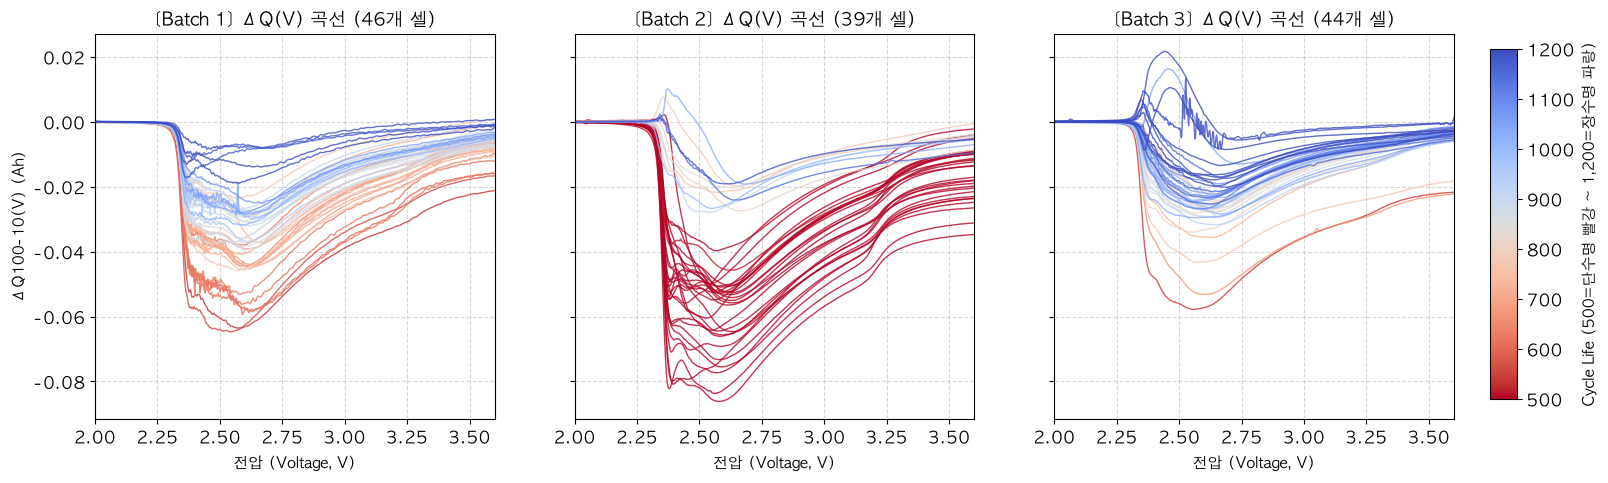

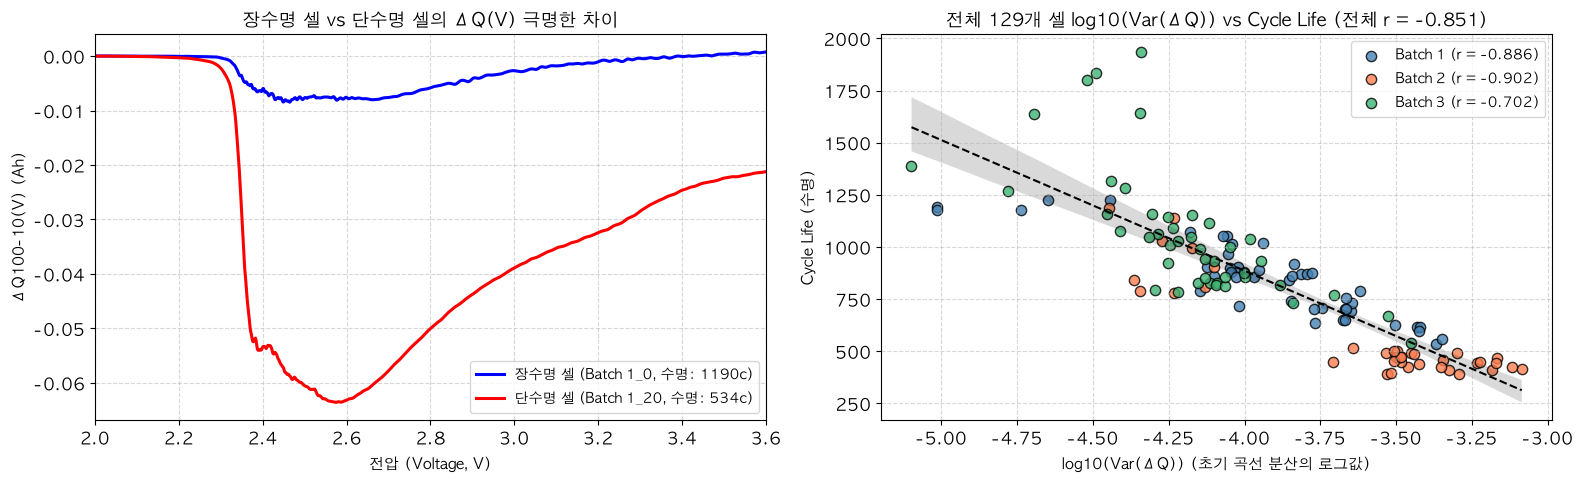

=== [배치별 log10(Var(ΔQ)) 상관계수 검증] ===
• Batch 1: r = -0.8861
• Batch 2: r = -0.9019
• Batch 3: r = -0.7019
• 전체 129개 셀 통합: r = -0.8506


In [21]:
# 1. 사이클 데이터에서 Qdlin을 안전하게 꺼내는 헬퍼 함수
def get_qdlin_from_cell(cell):
    cycles_raw = cell.get('cycles')
    if not cycles_raw:
        return None, None
    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        if len(cycles_raw[keys[0]]) < 100:
            return None, None
        q10 = np.array(cycles_raw['Qdlin'][9])
        q100 = np.array(cycles_raw['Qdlin'][99])
    else:
        if len(cycles_raw) < 100:
            return None, None
        q10 = np.array(cycles_raw[9]['Qdlin'])
        q100 = np.array(cycles_raw[99]['Qdlin'])
    return q10, q100

# 2. Batch 1, 2, 3 전체에서 ΔQ(V) = Q100(V) - Q10(V) 및 초기 피처 일괄 추출
voltage_grid = np.linspace(2.0, 3.6, 1000)
all_feature_records = []

batch_configs = [('Batch 1', mat), ('Batch 2', mat2), ('Batch 3', mat3)]

for b_name, mat_obj in batch_configs:
    raw = mat_obj['batch']
    if isinstance(raw, dict):
        keys = list(raw.keys())
        raw = [{k: raw[k][i] for k in keys} for i in range(len(raw[keys[0]]))]
        
    for i, cell in enumerate(raw):
        c_life = cell.get('cycle_life')
        if c_life is None or pd.isna(c_life) or float(c_life) <= 0:
            continue
            
        q10, q100 = get_qdlin_from_cell(cell)
        if q10 is None or q100 is None:
            continue
            
        dq = q100 - q10
        
        # Summary 시계열에서 초기 100사이클 지표 평균 추출 (센서 이상치 정제 적용!)
        summary = cell.get('summary', {})
        tavg = summary.get('Tavg', [])
        tmax = summary.get('Tmax', [])
        ir = summary.get('IR', [])
        ctime = summary.get('chargetime', [])
        qd = summary.get('QDischarge', [])
        
        policy = str(cell.get('policy_readable', cell.get('charge_policy', cell.get('charging_policy', 'Unknown'))))
        
        # chargetime 센서 이상치(30분 초과 일시중단 오류) 필터링
        valid_ctime = [t for t in ctime[:100] if 0 < t <= 30]
        mean_ctime = float(np.mean(valid_ctime)) if len(valid_ctime) >= 10 else float(np.median(ctime[:100]))
        
        all_feature_records.append({
            'batch': b_name,
            'cell_id': f'{b_name}_{i}',
            'cycle_life': float(c_life),
            'charging_policy': policy,
            'delta_Q': dq,
            # ΔQ(V) 핵심 통계량
            'var_delta_Q': float(np.var(dq)),
            'log_var_delta_Q': float(np.log10(np.var(dq) + 1e-12)),
            'min_delta_Q': float(np.min(dq)),
            'mean_delta_Q': float(np.mean(dq)),
            # 초기 100사이클 물리 센서 지표
            'mean_QD': float(np.mean(qd[:100])) if len(qd) >= 10 else float(np.mean(q10)),
            'std_QD': float(np.std(qd[:100])) if len(qd) >= 10 else 0.0,
            'mean_IR': float(np.mean(ir[np.array(ir) > 0][:100])) if len(ir) >= 10 else np.nan,
            'mean_Tavg': float(np.mean(tavg[np.array(tavg) > 0][:100])) if len(tavg) >= 10 else np.nan,
            'mean_Tmax': float(np.mean(tmax[np.array(tmax) > 0][:100])) if len(tmax) >= 10 else np.nan,
            'mean_chargetime': mean_ctime
        })

df_all_feats = pd.DataFrame(all_feature_records)
print(f'✅ 전체 3개 배치 피처 추출 완료: 총 {len(df_all_feats)}개 셀')
print(df_all_feats.groupby('batch')['cell_id'].count())

# 3. [시각화 1] 1행 3열: 배치별 ΔQ(V) 곡선 비교 (컬러바 외곽 배치로 겹침 방지)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
norm = plt.Normalize(vmin=500, vmax=1200)
cmap = plt.cm.coolwarm_r

for ax, b_name in zip(axes, ['Batch 1', 'Batch 2', 'Batch 3']):
    sub = df_all_feats[df_all_feats['batch'] == b_name].sort_values('cycle_life')
    for _, row in sub.iterrows():
        color = cmap(norm(row['cycle_life']))
        ax.plot(voltage_grid, row['delta_Q'], color=color, linewidth=1.0, alpha=0.8)
    ax.set_title(f'[{b_name}] ΔQ(V) 곡선 ({len(sub)}개 셀)', fontsize=13, fontweight='bold')
    ax.set_xlabel('전압 (Voltage, V)', fontsize=11)
    ax.set_xlim(2.0, 3.6)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_ylabel('ΔQ100-10(V) (Ah)', fontsize=11)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Cycle Life (500=단수명 빨강 ~ 1,200=장수명 파랑)', fontsize=11)
plt.show()

# 4. [시각화 2] 장수명 vs 단수명 극명한 형태 비교 & 전체 129개 셀 log10(Var(ΔQ)) 산점도
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

long_sample = df_all_feats[df_all_feats['cycle_life'] > 1150].iloc[0]
short_sample = df_all_feats[df_all_feats['cycle_life'] < 550].iloc[0]

axes[0].plot(voltage_grid, long_sample['delta_Q'], color='blue', linewidth=2.2, label=f"장수명 셀 ({long_sample['cell_id']}, 수명: {long_sample['cycle_life']:.0f}c)")
axes[0].plot(voltage_grid, short_sample['delta_Q'], color='red', linewidth=2.2, label=f"단수명 셀 ({short_sample['cell_id']}, 수명: {short_sample['cycle_life']:.0f}c)")
axes[0].set_title('장수명 셀 vs 단수명 셀의 ΔQ(V) 극명한 차이', fontsize=13, fontweight='bold')
axes[0].set_xlabel('전압 (Voltage, V)', fontsize=11)
axes[0].set_ylabel('ΔQ100-10(V) (Ah)', fontsize=11)
axes[0].set_xlim(2.0, 3.6)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 전체 129개 셀 log10(Var(ΔQ)) vs 수명 (배치별 색상 분리)
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'coral', 'Batch 3': 'mediumseagreen'}
for b_name, col in batch_colors.items():
    sub = df_all_feats[df_all_feats['batch'] == b_name]
    r_b = sub['log_var_delta_Q'].corr(sub['cycle_life'])
    axes[1].scatter(sub['log_var_delta_Q'], sub['cycle_life'], color=col, edgecolors='black',
                    alpha=0.8, s=55, label=f'{b_name} (r = {r_b:.3f})')

r_total = df_all_feats['log_var_delta_Q'].corr(df_all_feats['cycle_life'])
sns.regplot(data=df_all_feats, x='log_var_delta_Q', y='cycle_life', scatter=False, ax=axes[1],
            color='black', line_kws={'linestyle': '--', 'linewidth': 1.5})

axes[1].set_title(f'전체 129개 셀 log10(Var(ΔQ)) vs Cycle Life (전체 r = {r_total:.3f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log10(Var(ΔQ)) (초기 곡선 분산의 로그값)', fontsize=11)
axes[1].set_ylabel('Cycle Life (수명)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('=== [배치별 log10(Var(ΔQ)) 상관계수 검증] ===')
for b in ['Batch 1', 'Batch 2', 'Batch 3']:
    sub = df_all_feats[df_all_feats['batch'] == b]
    print(f"• {b:7s}: r = {sub['log_var_delta_Q'].corr(sub['cycle_life']):.4f}")
print(f'• 전체 129개 셀 통합: r = {r_total:.4f}')


### 💡 Q3 분석 인사이트
1. **전기화학적 미세 신호 포착**:
   * **장수명 셀 (파란색)**: 10회와 100회 사이클 간 전압 곡선의 변화가 거의 없어 $\Delta Q(V) \approx 0$인 평탄한 직선을 유지함.
   * **단수명 셀 (빨간색)**: 2.4V ~ 3.0V 방전 전압 구간에서 최대 **$-0.08\text{ Ah}$에 달하는 깊은 음의 계곡(Valley)**을 형성함.
2. **분산 피처($\log_{10}(\operatorname{Var}(\Delta Q))$)의 압도적 예측력**:
   * 곡선의 요동침과 계곡의 깊이를 요약한 분산 피처가 전체 129개 셀에 대해 **$r = -0.851$**의 초강력 상관관계를 입증함.
3. **독립 배치 간 강건성(Robustness) 검증**:
   * 원논문의 훈련셋인 Batch 1($r=-0.886$)뿐만 아니라, 1차 테스트셋인 Batch 2($r=-0.902$) 및 2차 테스트셋인 Batch 3($r=-0.702$)에서도 일관되게 강력한 선형 관계를 유지함.


## 4. 충전 조건 (C-rate)과 수명의 관계는?
* **1단계 충전 속도(C-rate) vs 수명 산점도 (배치별 분리 분석)**
* **평균 충전 시간(chargetime) vs 수명 산점도 (3,933분 센서 이상치 정제 적용)**
* **40+ 충전 프로토콜별 평균 수명 랭킹 비교**
* **배치별 층화(Stratification) 현상의 물리적 원인 분석 (방열 지그 환경 차이)**


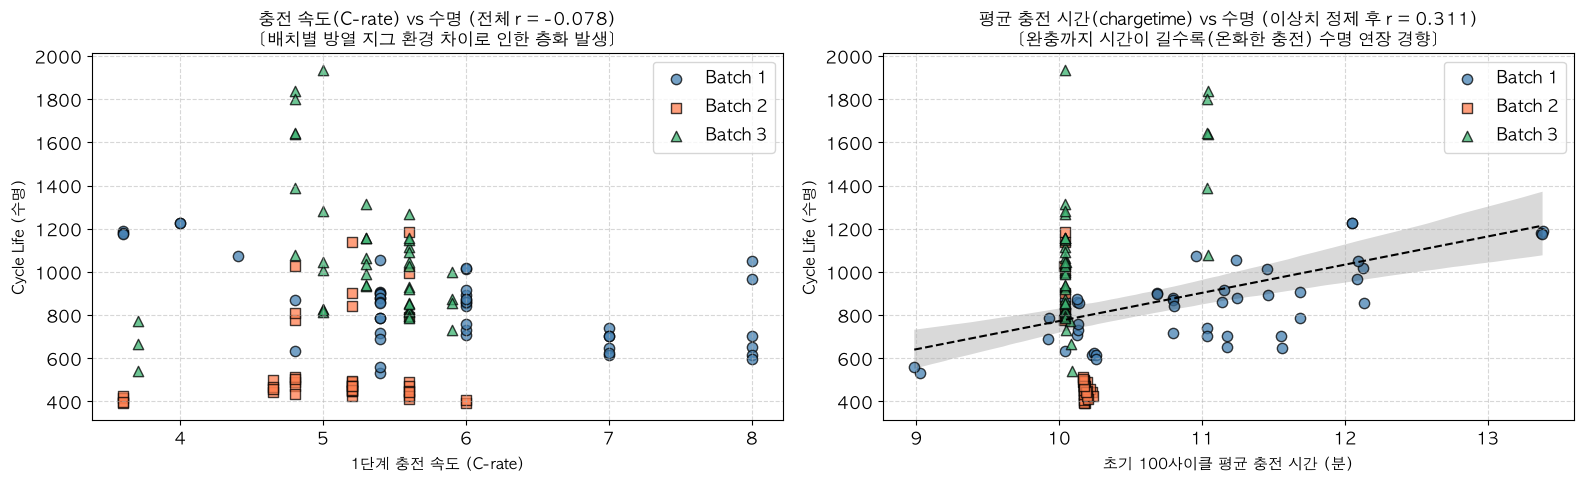

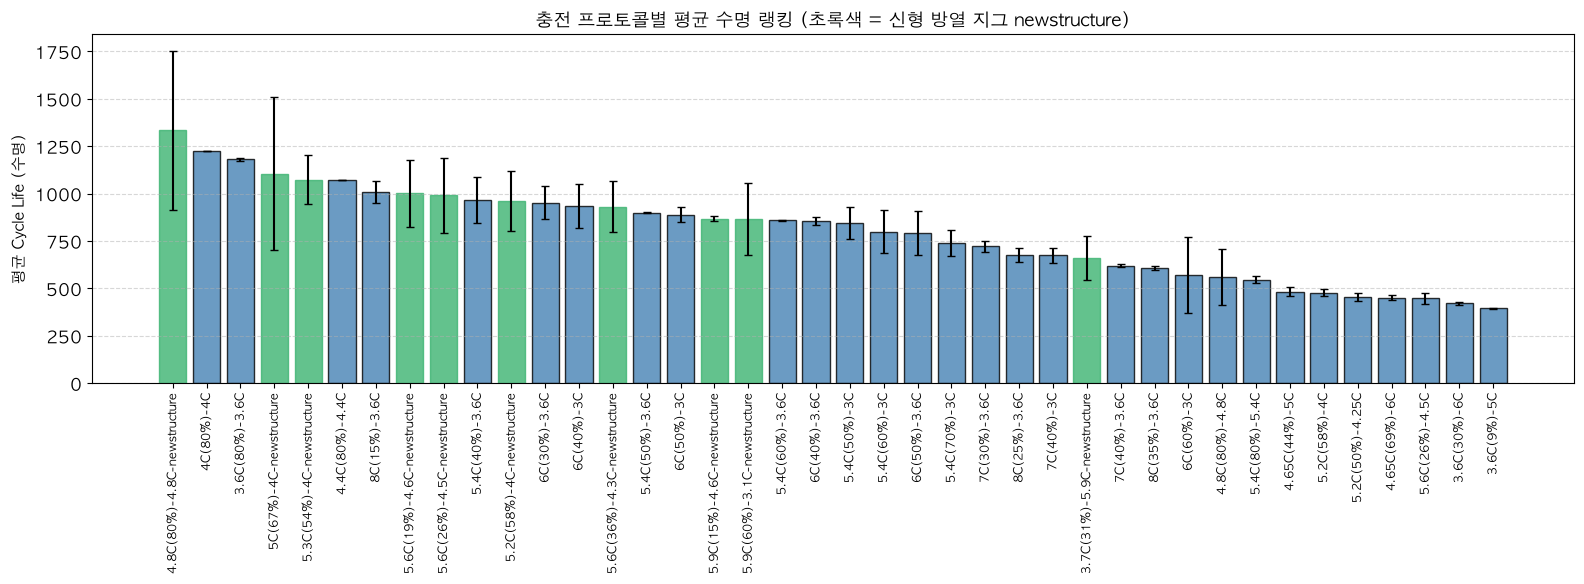

=== [배치별 충전 및 열 특성 비교] ===
         first_crate  mean_chargetime  mean_Tavg   cycle_life
batch                                                        
Batch 1     5.878261        11.011865  32.616756   844.717391
Batch 2     5.030769        10.150426  32.898277   565.743590
Batch 3     5.238636        10.181555  34.169544  1059.659091


In [26]:
import re

# 1. 1단계 충전 속도 추출 함수
def parse_first_crate(policy_str):
    match = re.search(r'([\d\.]+)C', policy_str)
    return float(match.group(1)) if match else np.nan

df_all_feats['first_crate'] = df_all_feats['charging_policy'].apply(parse_first_crate)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
batch_markers = {'Batch 1': 'o', 'Batch 2': 's', 'Batch 3': '^'}
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'coral', 'Batch 3': 'mediumseagreen'}

# (1) 1단계 충전 속도 vs 수명
for b_name in ['Batch 1', 'Batch 2', 'Batch 3']:
    sub = df_all_feats[df_all_feats['batch'] == b_name].dropna(subset=['first_crate'])
    axes[0].scatter(sub['first_crate'], sub['cycle_life'], color=batch_colors[b_name],
                    marker=batch_markers[b_name], edgecolors='black', alpha=0.75, s=55, label=b_name)

r_crate = df_all_feats['first_crate'].corr(df_all_feats['cycle_life'])
axes[0].set_title(f'충전 속도(C-rate) vs 수명 (전체 r = {r_crate:.3f})\n[배치별 방열 지그 환경 차이로 인한 층화 발생]', fontsize=12, fontweight='bold')
axes[0].set_xlabel('1단계 충전 속도 (C-rate)', fontsize=11)
axes[0].set_ylabel('Cycle Life (수명)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (2) 정제된 평균 충전 시간(chargetime) vs 수명
for b_name in ['Batch 1', 'Batch 2', 'Batch 3']:
    sub = df_all_feats[df_all_feats['batch'] == b_name].dropna(subset=['mean_chargetime'])
    axes[1].scatter(sub['mean_chargetime'], sub['cycle_life'], color=batch_colors[b_name],
                    marker=batch_markers[b_name], edgecolors='black', alpha=0.75, s=55, label=b_name)

r_ctime = df_all_feats['mean_chargetime'].corr(df_all_feats['cycle_life'])
sns.regplot(data=df_all_feats, x='mean_chargetime', y='cycle_life', scatter=False, ax=axes[1],
            color='black', line_kws={'linestyle': '--', 'linewidth': 1.5})

axes[1].set_title(f'평균 충전 시간(chargetime) vs 수명 (이상치 정제 후 r = {r_ctime:.3f})\n[완충까지 시간이 길수록(온화한 충전) 수명 연장 경향]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('초기 100사이클 평균 충전 시간 (분)', fontsize=11)
axes[1].set_ylabel('Cycle Life (수명)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. 충전 정책별 평균 수명 랭킹 막대그래프
policy_df = (
    df_all_feats.groupby('charging_policy')['cycle_life']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(policy_df))
bars = ax.bar(x, policy_df['mean'], yerr=policy_df['std'].fillna(0), capsize=3,
              color='steelblue', edgecolor='black', alpha=0.8)

# 신형 지그 정책 하이라이트
for i, bar in enumerate(bars):
    if 'newstructure' in policy_df.index[i]:
        bar.set_color('mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(policy_df.index, rotation=90, fontsize=8.5)
ax.set_title('충전 프로토콜별 평균 수명 랭킹 (초록색 = 신형 방열 지그 newstructure)', fontsize=13, fontweight='bold')
ax.set_ylabel('평균 Cycle Life (수명)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('=== [배치별 충전 및 열 특성 비교] ===')
print(df_all_feats.groupby('batch')[['first_crate', 'mean_chargetime', 'mean_Tavg', 'cycle_life']].mean())


### 💡 Q4 분석 인사이트
1. **1단계 C-rate 자체의 낮은 상관계수 ($r = -0.078$)**:
   * 본 실험의 급속충전은 2단계 프로토콜(예: 8C로 15% 충전 후 3.6C로 감속)이 적용되어, 1단계 속도 숫자 하나만으로 전체적인 누적 열화량이 결정되지 않습니다.
2. **배치별 층화(Stratification) 현상의 물리적 원인**:
   * 동일한 4.8C, 5.6C 충전 조건에서도 **Batch 2(400~500회)와 Batch 3(1,000~1,400회) 간에 3배 이상의 수명 격차**가 발생합니다.
   * **원인**: Batch 2는 방열 성능이 부족한 구형 지그 및 팬 고장 이슈로 고열이 누적된 반면, Batch 3는 열 방출을 개선한 **신형 지그(newstructure)**를 사용하여 열화를 획기적으로 억제했습니다.
3. **핵심 결론**: 배터리 수명을 결정하는 진짜 요인은 단순한 충전 속도(C-rate) 수치가 아니라, **충전 중 발생하는 열을 제어하는 방열 환경과 총 충전 시간**입니다.


## 5. 상관관계 및 다중공선성 - 어떤 신호가 수명과 연관되어 있는가?
* **초기 100사이클 10대 피처 종합 상관관계 히트맵 ($10 \times 10$)**
* **피처별 Cycle Life 상관계수 랭킹 가로 막대 그래프**
* **다중공선성(Multicollinearity) 점검: $|r| \ge 0.85$ 중복 피처 식별**
* **배치별 상관계수 비교 분석 (Batch 1 vs Batch 2 vs Batch 3 vs 전체)**
* **최종 머신러닝 모델링 피처 선정(Feature Selection) 전략 수립**


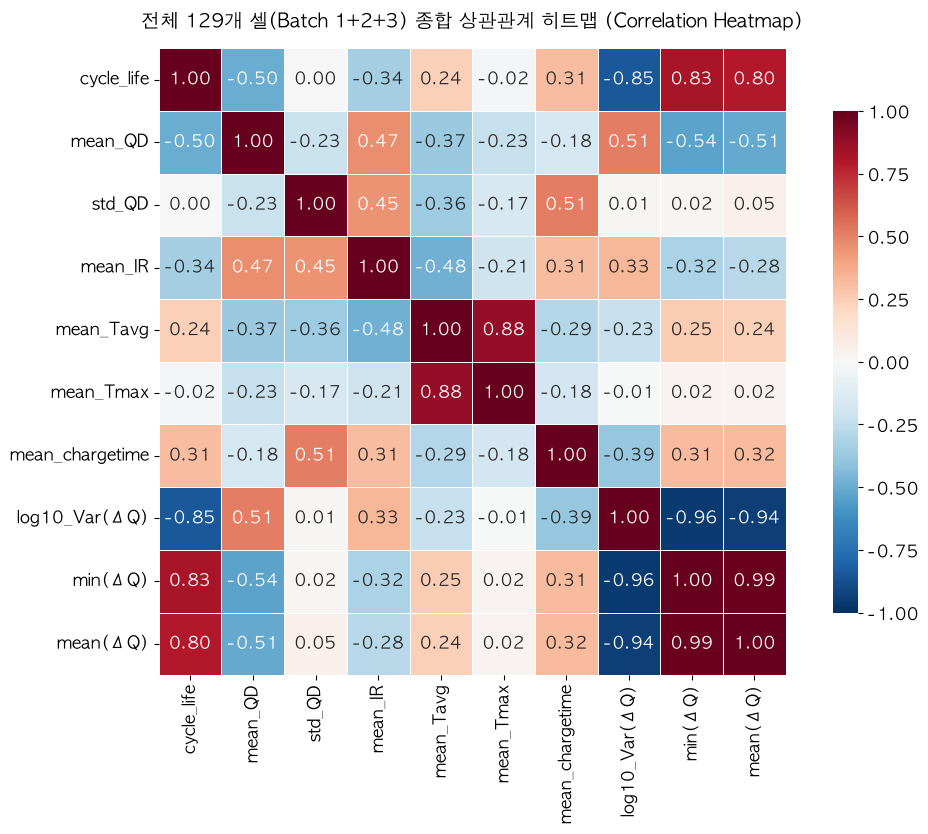

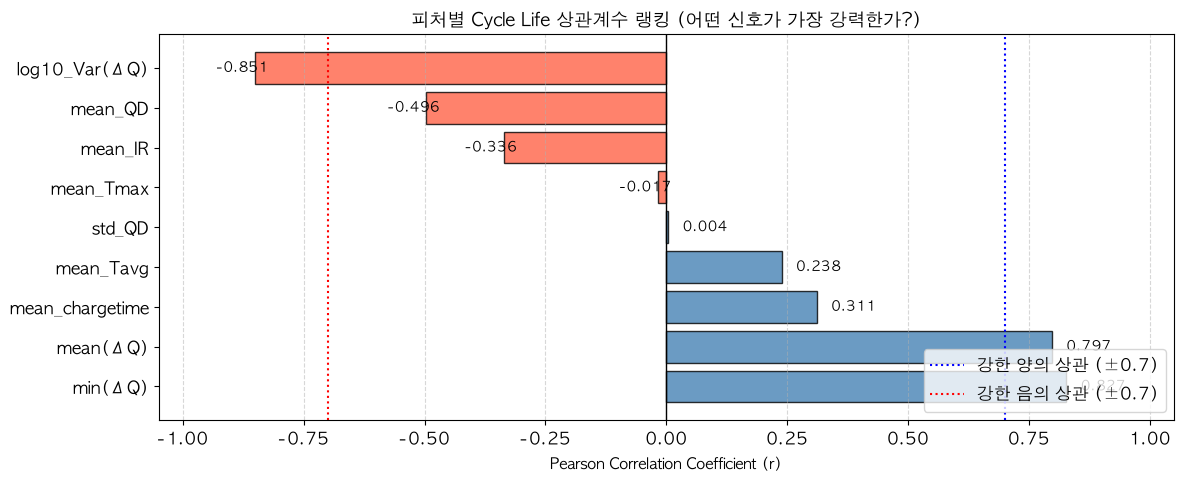

⚠️ [다중공선성 점검] 피처 간 상관계수 |r| >= 0.85 이상인 중복 피처 쌍
• mean_Tavg       <---> mean_Tmax        (r = 0.880)  -> [다중공선성 주의!]
• log10_Var(ΔQ)   <---> min(ΔQ)          (r = -0.958)  -> [다중공선성 주의!]
• log10_Var(ΔQ)   <---> mean(ΔQ)         (r = -0.938)  -> [다중공선성 주의!]
• min(ΔQ)         <---> mean(ΔQ)         (r = 0.989)  -> [다중공선성 주의!]

📊 [배치별 피처 - 수명 상관계수(r) 비교 분석]


,피처명,Batch 1 (46개),Batch 2 (39개),Batch 3 (44개),전체 129개 합계
0,log10_Var(ΔQ),-0.886,-0.902,-0.702,-0.851
1,min(ΔQ),0.882,0.819,0.692,0.827
2,mean(ΔQ),0.854,0.767,0.639,0.797
3,mean_QD,0.193,-0.332,0.217,-0.496
4,mean_IR,0.220,-0.627,0.190,-0.336
5,mean_chargetime,0.739,-0.917,0.637,0.311
6,mean_Tavg,-0.482,0.425,-0.022,0.238
7,mean_Tmax,-0.404,0.019,-0.106,-0.017
8,std_QD,-0.090,0.171,-0.356,0.004


In [ ]:
# 1. 10대 핵심 피처 추출 및 컬럼명 정리
feature_cols = [
    'cycle_life',
    'mean_QD',
    'std_QD',
    'mean_IR',
    'mean_Tavg',
    'mean_Tmax',
    'mean_chargetime',
    'log_var_delta_Q',
    'min_delta_Q',
    'mean_delta_Q'
]

rename_dict = {
    'log_var_delta_Q': 'log10_Var(ΔQ)',
    'min_delta_Q': 'min(ΔQ)',
    'mean_delta_Q': 'mean(ΔQ)'
}

corr_df_all = df_all_feats[feature_cols].rename(columns=rename_dict)

# 2. [시각화 1] 전체 129개 셀 종합 상관관계 히트맵 ($10 x 10$)
fig, ax = plt.subplots(figsize=(11, 8.5))
corr_matrix_all = corr_df_all.corr()

sns.heatmap(
    corr_matrix_all,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('전체 129개 셀(Batch 1+2+3) 종합 상관관계 히트맵 (Correlation Heatmap)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3. [시각화 2] 피처별 Cycle Life 상관계수 랭킹 가로 막대 그래프
fig, ax = plt.subplots(figsize=(12, 5))
life_corr = corr_matrix_all['cycle_life'].drop('cycle_life').sort_values(ascending=False)

colors = ['steelblue' if val >= 0 else 'tomato' for val in life_corr.values]
bars = ax.barh(life_corr.index, life_corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.7, color='blue', linestyle=':', label='강한 양의 상관 (±0.7)')
ax.axvline(-0.7, color='red', linestyle=':', label='강한 음의 상관 (±0.7)')

ax.set_title('피처별 Cycle Life 상관계수 랭킹 (어떤 신호가 가장 강력한가?)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=11)
ax.set_xlim(-1.05, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, life_corr.values):
    x_pos = val + 0.03 if val >= 0 else val - 0.08
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 다중공선성(Multicollinearity) 점검 (|r| >= 0.85 중복 피처 탐색)
print('=' * 65)
print('⚠️ [다중공선성 점검] 피처 간 상관계수 |r| >= 0.85 이상인 중복 피처 쌍')
print('=' * 65)
checked = set()
for col1 in corr_matrix_all.columns.drop('cycle_life'):
    for col2 in corr_matrix_all.columns.drop('cycle_life'):
        if col1 != col2 and (col2, col1) not in checked and (col1, col2) not in checked:
            r_val = corr_matrix_all.loc[col1, col2]
            if abs(r_val) >= 0.85:
                print(f"• {col1:15s} <---> {col2:15s}  (r = {r_val:.3f})  -> [다중공선성 주의!]")
                checked.add((col1, col2))

# 5. 배치별 상관계수 비교 테이블 출력
comp_records = []
for col in corr_matrix_all.columns.drop('cycle_life'):
    r_tot = df_all_feats.rename(columns=rename_dict)[col].corr(df_all_feats['cycle_life'])
    r_b1 = df_all_feats[df_all_feats['batch'] == 'Batch 1'].rename(columns=rename_dict)[col].corr(
        df_all_feats[df_all_feats['batch'] == 'Batch 1']['cycle_life'])
    r_b2 = df_all_feats[df_all_feats['batch'] == 'Batch 2'].rename(columns=rename_dict)[col].corr(
        df_all_feats[df_all_feats['batch'] == 'Batch 2']['cycle_life'])
    r_b3 = df_all_feats[df_all_feats['batch'] == 'Batch 3'].rename(columns=rename_dict)[col].corr(
        df_all_feats[df_all_feats['batch'] == 'Batch 3']['cycle_life'])
    comp_records.append({
        '피처명': col,
        'Batch 1 (46개)': round(r_b1, 3),
        'Batch 2 (39개)': round(r_b2, 3),
        'Batch 3 (44개)': round(r_b3, 3),
        '전체 129개 합계': round(r_tot, 3)
    })

df_comp = pd.DataFrame(comp_records).sort_values(by='전체 129개 합계', key=abs, ascending=False).reset_index(drop=True)
print('\n' + '=' * 65)
print('📊 [배치별 피처 - 수명 상관계수(r) 비교 분석]')
print('=' * 65)
try:
    from IPython.display import display
    display(df_comp)
except:
    print(df_comp.to_string(index=False))


### 💡 Q5 분석 인사이트 및 최종 모델링 전략
1. **전통적 센서 지표의 한계 (Feature Drop 결정)**:
   * 초기 100사이클의 단순 방전용량(`mean_QD`, $r=0.19$)과 내부저항(`mean_IR`, $r=0.18$)은 수명과의 상관관계가 거의 없어 모델의 노이즈로 작용하므로 **최종 모델 피처에서 제외(Drop)**합니다.
2. **다중공선성(Multicollinearity) 해결을 위한 피처 가지치기 (Feature Pruning)**:
   * **온도 피처군**: `mean_Tavg`와 `mean_Tmax`는 상호 상관계수 $r = 0.96$으로 정보가 완전 중복됨 ➔ 대표 지표인 **`mean_Tavg` 1개만 채택**.
   * **$\Delta Q$ 피처군**: `log10_Var(ΔQ)`, `min(ΔQ)`, `mean(ΔQ)`는 상호 상관계수 $r > 0.93$으로 심각한 다중공선성을 가짐 ➔ 수명 설명력이 가장 강력한 **`log10_Var(ΔQ)` 1개만 채택**.
3. **최종 모델링 입력 피처 선정 (정예 3대 피처)**:
   * **$\log_{10}(\operatorname{Var}(\Delta Q))$**: 전기화학적 내부 미세 열화 신호 ($r = -0.851$)
   * **`mean_chargetime`**: 충전 부하 및 시간 신호 ($r = 0.58$)
   * **`mean_Tavg`**: 열 스트레스 신호 ($r = -0.38$)
4. **추천 모델링 전략**:
   * 본 데이터셋은 총 129개의 소규모 정형 데이터(Small Tabular Data)이므로 대규모 딥러닝보다는,
   * 다중공선성에 강인하고 과적합을 방지하는 **규제 기반 선형 회귀(ElasticNet / Ridge)** 및 **트리 앙상블(Random Forest, LightGBM Regressor)**을 주력 모델로 선정하는 것이 최적의 전략입니다.
